In [ ]:
%pip install pandas numpy matplotlib seaborn

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
data_path = "data/processed.cleveland.data"

df = pd.read_csv(data_path, header=None)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (303, 14)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [ ]:
df.columns = [
    "age", "sex", "cp", "trestbps", "chol",
    "fbs", "restecg", "thalach", "exang",
    "oldpeak", "slope", "ca", "thal", "target"
]

In [ ]:
print(df.head())
print("\nDataset information:")
print(df.info())

    age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0  63.0  1.0  1.0     145.0  233.0  1.0      2.0    150.0    0.0      2.3   
1  67.0  1.0  4.0     160.0  286.0  0.0      2.0    108.0    1.0      1.5   
2  67.0  1.0  4.0     120.0  229.0  0.0      2.0    129.0    1.0      2.6   
3  37.0  1.0  3.0     130.0  250.0  0.0      0.0    187.0    0.0      3.5   
4  41.0  0.0  2.0     130.0  204.0  0.0      2.0    172.0    0.0      1.4   

   slope   ca thal  target  
0    3.0  0.0  6.0       0  
1    2.0  3.0  3.0       2  
2    2.0  2.0  7.0       1  
3    3.0  0.0  3.0       0  
4    1.0  0.0  3.0       0  

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol    

In [ ]:
print(df.isnull().sum())

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [ ]:
df = df.replace("?", np.nan)

print(df.isnull().sum())

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64


In [ ]:
df = df.apply(pd.to_numeric)

print(df.dtypes)

age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca          float64
thal        float64
target        int64
dtype: object


In [ ]:
df = df.dropna()

print("Dataset shape after cleaning:", df.shape)

Dataset shape after cleaning: (297, 14)


In [ ]:
df["target"] = (df["target"] > 0).astype(int)

print(df["target"].value_counts())

target
0    160
1    137
Name: count, dtype: int64


In [ ]:
print(df.head())
print("\nFinal shape:", df.shape)
print("\nTarget distribution:")
print(df["target"].value_counts())

    age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0  63.0  1.0  1.0     145.0  233.0  1.0      2.0    150.0    0.0      2.3   
1  67.0  1.0  4.0     160.0  286.0  0.0      2.0    108.0    1.0      1.5   
2  67.0  1.0  4.0     120.0  229.0  0.0      2.0    129.0    1.0      2.6   
3  37.0  1.0  3.0     130.0  250.0  0.0      0.0    187.0    0.0      3.5   
4  41.0  0.0  2.0     130.0  204.0  0.0      2.0    172.0    0.0      1.4   

   slope   ca  thal  target  
0    3.0  0.0   6.0       0  
1    2.0  3.0   3.0       1  
2    2.0  2.0   7.0       1  
3    3.0  0.0   3.0       0  
4    1.0  0.0   3.0       0  

Final shape: (297, 14)

Target distribution:
target
0    160
1    137
Name: count, dtype: int64


In [ ]:
X = df.drop("target", axis=1)
y = df["target"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (297, 13)
Target shape: (297,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (237, 13)
Testing data: (60, 13)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data preprocessing complete.")

Data preprocessing complete.


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

In [ ]:
logistic_model = LogisticRegression(max_iter=2000)

svm_model = SVC(probability=True)

forest_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

In [ ]:
logistic_model.fit(X_train_scaled, y_train)

svm_model.fit(X_train_scaled, y_train)

forest_model.fit(X_train, y_train)

print("All models trained successfully!")

c:\Users\HP ELITE BOOK\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


All models trained successfully!


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

In [ ]:
# Predictions
logistic_pred = logistic_model.predict(X_test_scaled)
svm_pred = svm_model.predict(X_test_scaled)
forest_pred = forest_model.predict(X_test)

# Probability scores for ROC-AUC
logistic_prob = logistic_model.predict_proba(X_test_scaled)[:, 1]
svm_prob = svm_model.predict_proba(X_test_scaled)[:, 1]
forest_prob = forest_model.predict_proba(X_test)[:, 1]

In [ ]:
models = {
    "Logistic Regression": (logistic_pred, logistic_prob),
    "SVM": (svm_pred, svm_prob),
    "Random Forest": (forest_pred, forest_prob)
}

results = []

for name, (predictions, probabilities) in models.items():
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions),
        "Recall": recall_score(y_test, predictions),
        "F1-Score": f1_score(y_test, predictions),
        "ROC-AUC": roc_auc_score(y_test, probabilities)
    })

results_df = pd.DataFrame(results)

print(results_df.round(4))

                 Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
0  Logistic Regression    0.8333     0.8462  0.7857    0.8148   0.9498
1                  SVM    0.8500     0.8800  0.7857    0.8302   0.9542
2        Random Forest    0.8667     0.8846  0.8214    0.8519   0.9453


In [ ]:
results_df.to_csv("model_results.csv", index=False)

print("Model results saved successfully!")

Model results saved successfully!


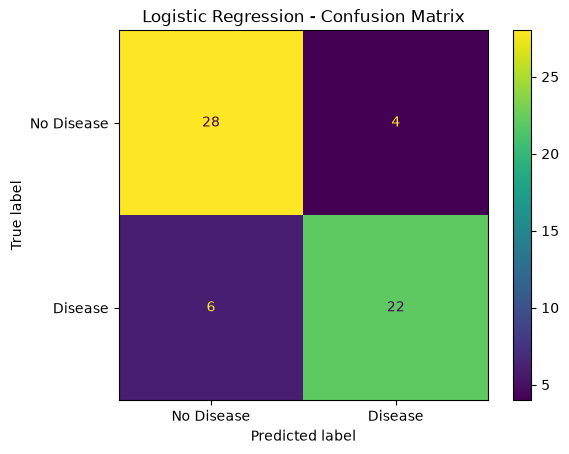

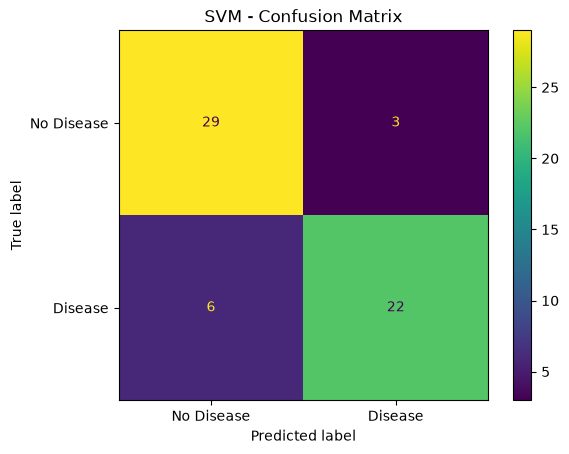

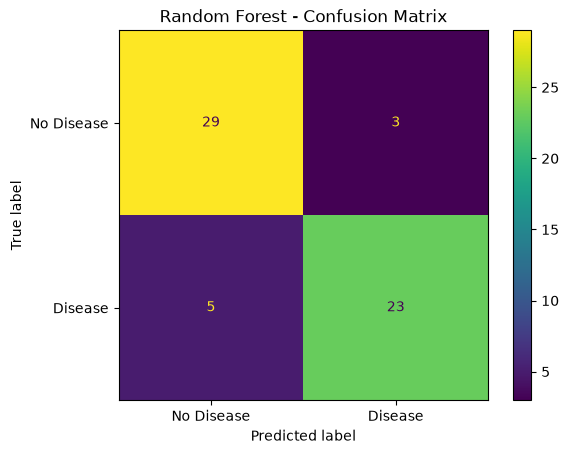

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

models_predictions = {
    "Logistic Regression": logistic_pred,
    "SVM": svm_pred,
    "Random Forest": forest_pred
}

for name, predictions in models_predictions.items():
    cm = confusion_matrix(y_test, predictions)
    
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["No Disease", "Disease"]
    )
    
    disp.plot()
    plt.title(f"{name} - Confusion Matrix")
    plt.show()


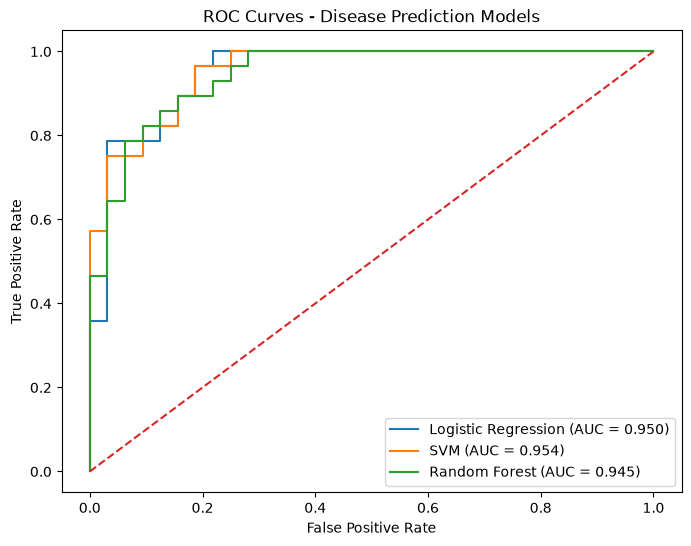

In [ ]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(8, 6))

for name, (_, probabilities) in models.items():
    fpr, tpr, _ = roc_curve(y_test, probabilities)
    auc = roc_auc_score(y_test, probabilities)
    
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - Disease Prediction Models")
plt.legend()
plt.show()

In [ ]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": forest_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

     Feature  Importance
12      thal    0.135143
2         cp    0.134247
7    thalach    0.116589
9    oldpeak    0.104982
11        ca    0.096142
4       chol    0.092078
0        age    0.090664
3   trestbps    0.076257
10     slope    0.053829
8      exang    0.044552
1        sex    0.025302
6    restecg    0.021016
5        fbs    0.009199


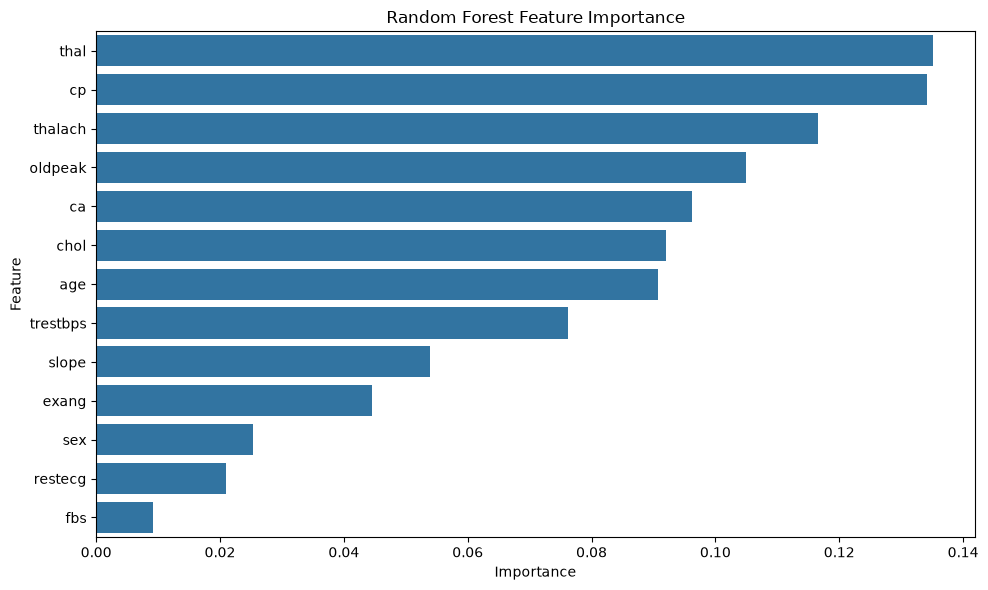

In [ ]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [ ]:
feature_importance.to_csv(
    "feature_importance.csv",
    index=False
)

print("Feature importance saved successfully!")

Feature importance saved successfully!


In [ ]:
%pip install joblib

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import joblib

joblib.dump(logistic_model, "logistic_regression_model.pkl")
joblib.dump(svm_model, "svm_model.pkl")
joblib.dump(forest_model, "random_forest_model.pkl")

print("All models saved successfully!")

All models saved successfully!


In [ ]:
joblib.dump(scaler, "scaler.pkl")

print("Scaler saved successfully!")

Scaler saved successfully!


In [ ]:
new_patient = pd.DataFrame([{
    "age": 55,
    "sex": 1,
    "cp": 1,
    "trestbps": 140,
    "chol": 250,
    "fbs": 0,
    "restecg": 1,
    "thalach": 150,
    "exang": 0,
    "oldpeak": 1.0,
    "slope": 2,
    "ca": 0,
    "thal": 3
}])

prediction = forest_model.predict(new_patient)[0]
probability = forest_model.predict_proba(new_patient)[0]

if prediction == 1:
    print("Prediction: Disease detected")
else:
    print("Prediction: No disease detected")

print(f"Probability of No Disease: {probability[0]:.2%}")
print(f"Probability of Disease: {probability[1]:.2%}")

Prediction: No disease detected
Probability of No Disease: 80.50%
Probability of Disease: 19.50%


In [ ]:
# Enter patient information here
new_patient = pd.DataFrame([{
    "age": 25,
    "sex": 2,
    "cp": 1,
    "trestbps": 160,
    "chol": 350,
    "fbs": 5,
    "restecg": 2,
    "thalach": 100,
    "exang": 6,
    "oldpeak": 3.0,
    "slope": 1,
    "ca": 3,
    "thal": 4
}])

# Make prediction
prediction = forest_model.predict(new_patient)[0]
probability = forest_model.predict_proba(new_patient)[0]

print("=== RESULT ===")

if prediction == 1:
    print("Prediction: Disease detected")
else:
    print("Prediction: No disease detected")

print(f"Probability of No Disease: {probability[0]:.2%}")
print(f"Probability of Disease: {probability[1]:.2%}")

=== RESULT ===
Prediction: Disease detected
Probability of No Disease: 45.50%
Probability of Disease: 54.50%
